# Perovskite Energy Yield with Degradation
Predicts real-world operational lifetime ($T_{80}$, $T_{90,Agg}$) and hourly energy yield of a
single-junction perovskite solar cell using the combined **Arrhenius + power-law** degradation model of
Orooji et al. (2026), parameterised from the accelerated aging data of Zhao et al. (2022).

**Models covered:**
1. **Device-level CE degradation factor** — `perovskite_degradation_factor()` (D046, CsPbI₃)
2. **Energy yield with pvlib single-diode model** — `degraded_power_ratio()` computes hourly $P_{mp}$,
   aggregated power ratio $PR_{Agg}(t)$, and $T_{90,Agg}$.
3. **Multi-location comparison** — Assess multiple locations with T₈₀ and T₉₀ thresholds.

**Key equations:**

$$k(T_i, I_i) = k_0 \cdot \exp\!\left(\frac{-E_a}{k_B T_i}\right) \cdot \left(\frac{I_i}{I_{ref}}\right)^{\!\gamma}$$

$$DF(i) = A_1 e^{-k_{fast} \cdot 1\text{h}} + A_2 e^{-k_{slow} \cdot 1\text{h}} + B
\qquad
DF_{total}(t) = \prod_{i=1}^{t} DF(i)$$

$$PR_{Agg}(t) = \frac{\sum_{i=1}^{t} P_{deg}(i)}{\sum_{i=1}^{t} P_{ref}(i)}$$

**References:**
- Orooji et al. (2026) *EES Solar*. doi: 10.1039/d6el00021e
- Zhao et al. (2022) *Science* 377, 307–310. doi: 10.1126/science.abn5679

## 1. Imports and data

In [1]:
import os
import json
import tempfile
import pvlib
import numpy as np
import pandas as pd
import pvdeg
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import plotly.express as px
import plotly.graph_objects as go

REPO_ROOT = os.path.dirname(os.path.dirname(pvdeg.__file__))
TUTORIALS_DATA = os.path.join(REPO_ROOT, "tutorials", "data")

# Redirect all Scenario job folders to the system temp directory.
# Keeps the repo working directory free of pvd_job_* clutter.
pvdeg.config.SCENARIO_OUTPUT_PATH = tempfile.gettempdir()

# Lifetime threshold e.g. 0.90 for T90
T_THRESHOLD = 0.90
T_LABEL = f"T{int(T_THRESHOLD * 100)}"  # e.g. "T90" or "T80"

# Note: Orooji et al. (2026) model the energy yield of a Perovskite/Si tandem device
# using LTspice and EYCalc, including only degradation of the top cell. For simplicity,
# this example models the degradation and subsequent energy yield of a single-junction
# perovskite top cell, using the same published perovskite top cell parameters.
TOP_CELL_PARAM = {
    "I_sc_ref": 0.02076,  # A   (Jsc 20.76 mA/cm^2 for 1 cm^2; tandem current-matched)
    "I_0_ref": 2.6e-18,  # A   (J0 = 2.6e-18 A/cm^2)
    "R_s": 1.4,  # Ohm (1.4 Ohm.cm^2)
    "R_sh": 1300.0,  # Ohm (1300 Ohm.cm^2)
    "n_diode": 1.3,  # ideality factor
}

In [2]:
# Use some local data shipped with pvdeg first to avoid API calls
LOCATIONS = {
    "Golden, CO": ("psm4_golden.csv", "meta_golden.json"),
    "Miami, FL": ("psm4_miami.csv", "meta_miami.json"),
    "New York, NY": ("psm4_nyc.csv", "meta_nyc.json"),
}

all_weather, all_meta = {}, {}
for loc, (wf, mf) in LOCATIONS.items():
    df = pd.read_csv(
        os.path.join(TUTORIALS_DATA, wf),
        index_col=0,
        parse_dates=True,
    )
    df.index = df.index.map(lambda ts: ts.replace(year=2020))
    df = df.sort_index()
    with open(os.path.join(TUTORIALS_DATA, mf)) as _f:
        mt = json.load(_f)
    all_weather[loc], all_meta[loc] = df, mt
    print(f"  {loc}: {len(df)} rows  ({mt['latitude']:.2f}°N, {mt['longitude']:.2f}°E)")

# Single-location aliases used by the EY demonstration cells below
weather_df = all_weather["Golden, CO"]
meta = all_meta["Golden, CO"]
display_year = 2020

  Golden, CO: 8760 rows  (39.73°N, -105.18°E)
  Miami, FL: 8760 rows  (25.77°N, -80.18°E)
  New York, NY: 8760 rows  (40.65°N, -73.98°E)


---
## 2. Zhao / Orooji degradation parameters (D046)

The model is parameterised from the **uncapped CsPbI₃** device in Zhao et al. (2022),
which was aged at 35–110 °C under ~1200 W m⁻² continuous illumination.
Activation energies come directly from the Arrhenius plot (Fig. 3C of the paper):

| Parameter | Value | Meaning |
|-----------|-------|---------|
| $E_{a,fast}$ | 0.248 eV | Activation energy of the fast degradation process |
| $E_{a,slow}$ | 0.243 eV | Activation energy of the slow degradation process |
| $A_1$ | 0.25 | Amplitude of the fast exponential |
| $A_2$ | 0.70 | Amplitude of the slow exponential |
| $B$ | 0.05 | Residual stable fraction (long-term plateau) |
| $\gamma$ | 1.0 | Light-intensity exponent |
| $I_{ref}$ | 1200 W m⁻² | Reference irradiance of the aging experiment |

These are stored in `DegradationDatabase.json` entry **D046** and loaded below.

In [3]:
d046 = pvdeg.utilities.get_kinetics("D046")

print("D046 — Zhao et al. 2022 (uncapped CsPbI₃, doi: 10.1126/science.abn5679)")
skip = {
    "DataEntryPerson",
    "DateEntered",
    "doi",
    "SourceTitle",
    "Authors",
    "Reference",
    "Material",
    "EquationType",
    "Comments",
}
for k, v in d046.items():
    if k not in skip:
        print(f"  {k}: {v}")

D046 — Zhao et al. 2022 (uncapped CsPbI₃, doi: 10.1126/science.abn5679)
  Ea_fast: 0.248
  Ea_slow: 0.243
  k0_fast: 0.56
  k0_slow: 0.48
  A1: 0.25
  A2: 0.7
  B: 0.05
  gamma: 1.0
  I_ref: 1200.0


---
## 3. Scenario pipeline — CE factor and module temperature

Three jobs run inside the Scenario pipeline. `degraded_power_ratio()` returns a `dict`
(which the Scenario pipeline does not store), so it is called directly afterwards with
the pipeline outputs.

| Step | Function | Output name | Depends on |
|------|----------|-------------|------------|
| 1 | `spectral.poa_irradiance` | `"poa"` | — |
| 2 | `temperature.module` | `"temp_mod"` | `poa` ← `"poa"` |
| 3 | `degradation.perovskite_degradation_factor` (D046) | `"ce_factor"` | `poa` ← `"poa"` |

In [4]:
scenarios = {}
for loc in LOCATIONS:
    sc = pvdeg.Scenario(
        name=f"ey-{loc.split(',')[0].lower().replace(' ', '-')}",
        weather_data=all_weather[loc],
        meta_data=all_meta[loc],
    )
    sc.addJob(
        func=(
            pvdeg.spectral.poa_irradiance,
            {
                "surface_tilt": abs(all_meta[loc]["latitude"]),
                "surface_azimuth": 180.0,
            },
        ),
        name="poa",
    )
    sc.addJob(
        func=pvdeg.temperature.module,
        name="temp_mod",
        depends_on={"poa": "poa"},
    )
    sc.addJob(
        func=(pvdeg.degradation.perovskite_degradation_factor, {"parameters": d046}),
        name="ce_factor",
        depends_on={"poa": "poa"},
    )
    sc.run()
    scenarios[loc] = sc
    print(f"  {loc}: CE@year-end = {sc.results['ce_factor'].iloc[-1]:.4f}")

# Golden, CO aliases for the EY cells below
s = scenarios["Golden, CO"]
ce_factor = s.results["ce_factor"]
poa_df = s.results["poa"]
temp_mod = s.results["temp_mod"]

The array surface_tilt angle was not provided, therefore the latitude of  39.7 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
  Golden, CO: CE@year-end = 0.9052
The array surface_tilt angle was not provided, therefore the latitude of  25.8 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
  Miami, FL: CE@year-end = 0.8799
The array surface_tilt angle was not provided, therefore the latitude of  40.6 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
  New York, NY: CE@year-end = 0.9220


---
## 4. Energy yield with a single-diode model

`degraded_power_ratio()` calls `pvlib.pvsystem.singlediode()` at each hourly timestep.
The photocurrent is scaled by the CE factor:

$$I_L^{deg}(t) = I_{sc,ref} \cdot \frac{G(t)}{G_{ref}} \cdot [1 + \alpha_{ISC}(T_{cell}(t) - T_{ref})] \cdot CE_{factor}(t)$$

Diode parameters are defined in `TOP_CELL_PARAM`. While the original reference models
the energy yield of a tandem architecture with degradation experienced in this top cell only, for simplicity we model only the energy yield of this top cell as a single junction device with the degradation calculated in the same way.

In [5]:
ce_factor = s.results["ce_factor"]
poa_df = s.results["poa"]
temp_mod = s.results["temp_mod"]

ey = pvdeg.degradation.degraded_power_ratio(
    weather_df=weather_df,
    meta=meta,
    ce_factor=ce_factor,
    poa=poa_df,
    temp_cell=temp_mod,
    **TOP_CELL_PARAM,
)

PR_Agg = ey["PR_Agg"]
power_degraded = ey["power_degraded"]
power_reference = ey["power_reference"]

# Compute threshold crossing using T_THRESHOLD (set in the imports cell)
t_agg_idx = PR_Agg[PR_Agg <= T_THRESHOLD].index
if len(t_agg_idx):
    T_Agg_months = (
        (t_agg_idx[0] - PR_Agg.index[0]).total_seconds() / 3600 / (24 * 365.25 / 12)
    )
    print(f"{T_LABEL},Agg = {T_Agg_months:.1f} months")
else:
    end_pr = PR_Agg.iloc[-1]
    print(f"{T_LABEL},Agg not reached in 1 year  (PR_Agg at year-end = {end_pr:.4f})")
    print(f"CE factor at year-end = {ce_factor.iloc[-1]:.4f}")
    print(
        "Consistent with the paper's prediction of ~26–42 months depending on climate."
    )

T90,Agg not reached in 1 year  (PR_Agg at year-end = 0.9492)
CE factor at year-end = 0.9052
Consistent with the paper's prediction of ~26–42 months depending on climate.


Text(0.5, 1.01, 'Zhao/Orooji D046  |  Golden PR_Agg = 0.9492 at year-end')

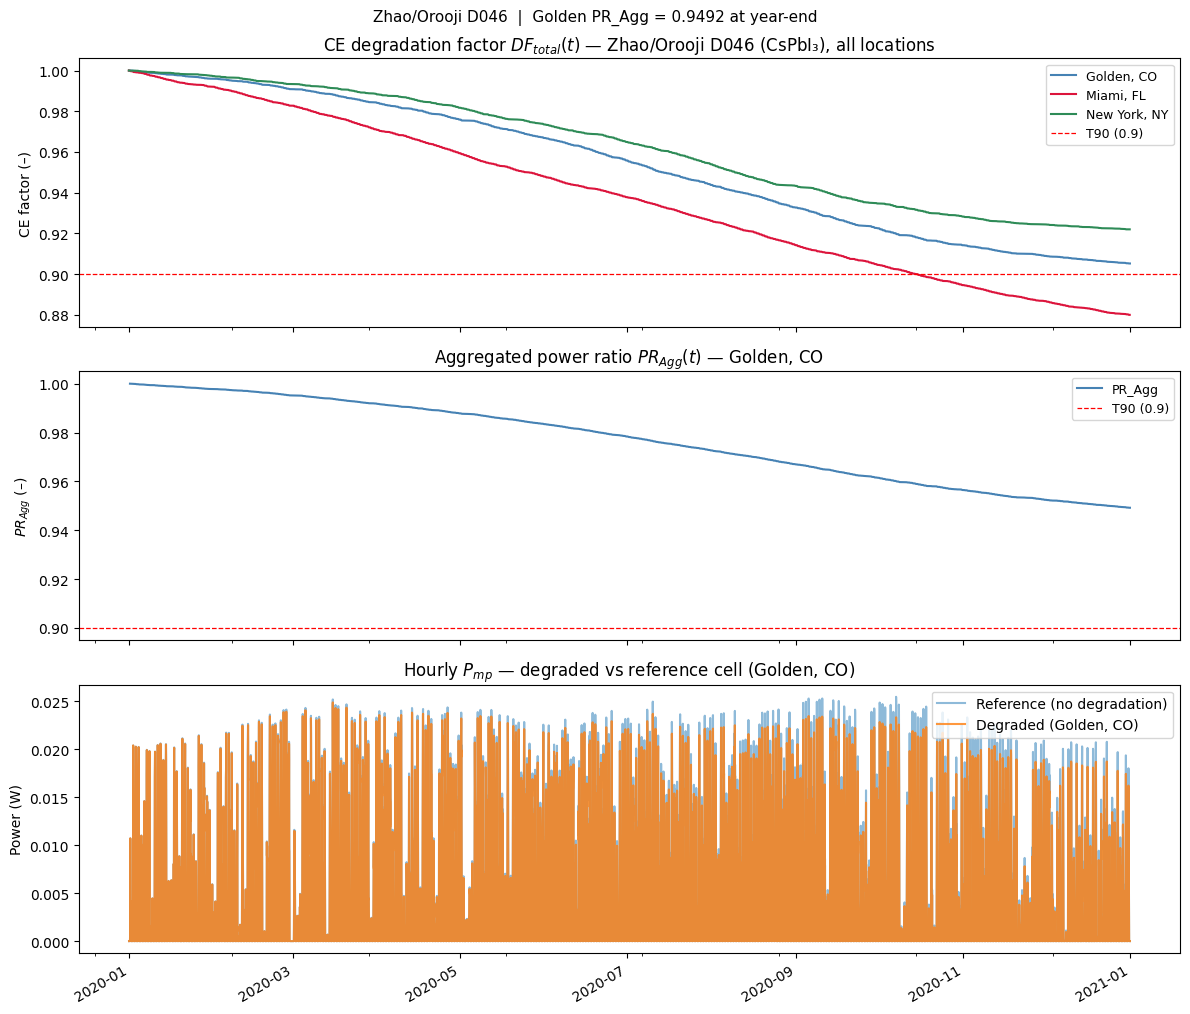

In [6]:
_colors = {
    "Golden, CO": "steelblue",
    "Miami, FL": "crimson",
    "New York, NY": "seagreen",
}

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Panel 1: CE degradation factor — all locations + threshold line
for loc, sc in scenarios.items():
    sc.results["ce_factor"].plot(ax=axes[0], label=loc, color=_colors[loc])
axes[0].axhline(
    T_THRESHOLD,
    color="red",
    linestyle="--",
    linewidth=0.9,
    label=f"{T_LABEL} ({T_THRESHOLD})",
)
axes[0].set_ylabel("CE factor (–)")
axes[0].set_title(
    f"CE degradation factor $DF_{{total}}(t)$ — Zhao/Orooji D046 (CsPbI₃), all locations"
)
axes[0].legend(fontsize=9, loc="upper right")

# Panel 2: Aggregated power ratio — Golden, CO
PR_Agg.plot(ax=axes[1], color="steelblue")
axes[1].axhline(
    T_THRESHOLD,
    color="red",
    linestyle="--",
    linewidth=0.9,
    label=f"{T_LABEL} ({T_THRESHOLD})",
)
axes[1].set_ylabel("$PR_{Agg}$ (–)")
axes[1].set_title(f"Aggregated power ratio $PR_{{Agg}}(t)$ — Golden, CO")
axes[1].legend(fontsize=9)

# Panel 3: Hourly power — degraded vs reference, Golden, CO
power_reference.plot(ax=axes[2], label="Reference (no degradation)", alpha=0.5)
power_degraded.plot(ax=axes[2], label="Degraded (Golden, CO)", alpha=0.8)
axes[2].set_ylabel("Power (W)")
axes[2].set_title("Hourly $P_{mp}$ — degraded vs reference cell (Golden, CO)")
axes[2].legend()

fig.tight_layout()
plt.suptitle(
    f"Zhao/Orooji D046  |  Golden PR_Agg = {PR_Agg.iloc[-1]:.4f} at year-end",
    y=1.01,
    fontsize=11,
)

---
## 5. Multi-year lifetime projection — finding the threshold crossing

One year of data is not enough to cross the `T_THRESHOLD` at any location. The standard approach
is to **tile** the same meteorological year across N years, which matches the methodology of
Orooji et al. (2026). The running product in `perovskite_degradation_factor()` accumulates
continuously, so the full N-year series is passed as a single concatenated input.


In [7]:
N_YEARS = 3  # increase if no location reaches T_THRESHOLD within the window


def make_multiyear(df, n_years, start_year=2020):
    """Tile a 1-year weather DataFrame across n_years by shifting the year index."""
    frames = []
    for y in range(n_years):
        yr = start_year + y
        f = df.copy()
        f.index = f.index.map(lambda ts, _yr=yr: ts.replace(year=_yr))
        frames.append(f)
    return pd.concat(frames).sort_index()


def run_ce_multiyear(wdf, mt, n_years=N_YEARS):
    """Run POA → CE factor on tiled N-year weather (no EY calculation).

    Passes explicit tilt (|latitude|) and south-facing azimuth (180°) to suppress
    the poa_irradiance default-assumption warning.
    Job folders go to pvdeg.config.SCENARIO_OUTPUT_PATH (set in the imports cell).
    """
    wdf_ny = make_multiyear(wdf, n_years)
    tilt = abs(mt["latitude"])
    sc = pvdeg.Scenario(name="ce-multiyear", weather_data=wdf_ny, meta_data=mt)
    sc.addJob(
        func=(
            pvdeg.spectral.poa_irradiance,
            {
                "surface_tilt": tilt,
                "surface_azimuth": 180.0,
            },
        ),
        name="poa",
    )
    sc.addJob(
        func=(pvdeg.degradation.perovskite_degradation_factor, {"parameters": d046}),
        name="ce_factor",
        depends_on={"poa": "poa"},
    )
    sc.run()
    return sc.results["ce_factor"]


print(
    f"Running {N_YEARS}-year CE projection for all locations  (threshold = {T_LABEL})..."
)
ce_multiyear = {}
for loc in LOCATIONS:
    print(f"  {loc}...", end="  ")
    ce_multiyear[loc] = run_ce_multiyear(all_weather[loc], all_meta[loc])
    t_idx = ce_multiyear[loc][ce_multiyear[loc] <= T_THRESHOLD].index
    if len(t_idx):
        t_months = (t_idx[0] - ce_multiyear[loc].index[0]).days / 30.44
        print(f"{T_LABEL} at {t_months:.1f} months")
    else:
        print(f"{T_LABEL} not reached in {N_YEARS} years")

Running 3-year CE projection for all locations  (threshold = T90)...
  Golden, CO...  The array surface_tilt angle was not provided, therefore the latitude of  39.7 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
T90 at 13.4 months
  Miami, FL...  The array surface_tilt angle was not provided, therefore the latitude of  25.8 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
T90 at 9.4 months
  New York, NY...  The array surface_tilt angle was not provided, therefore the latitude of  40.6 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
T90 at 16.5 months


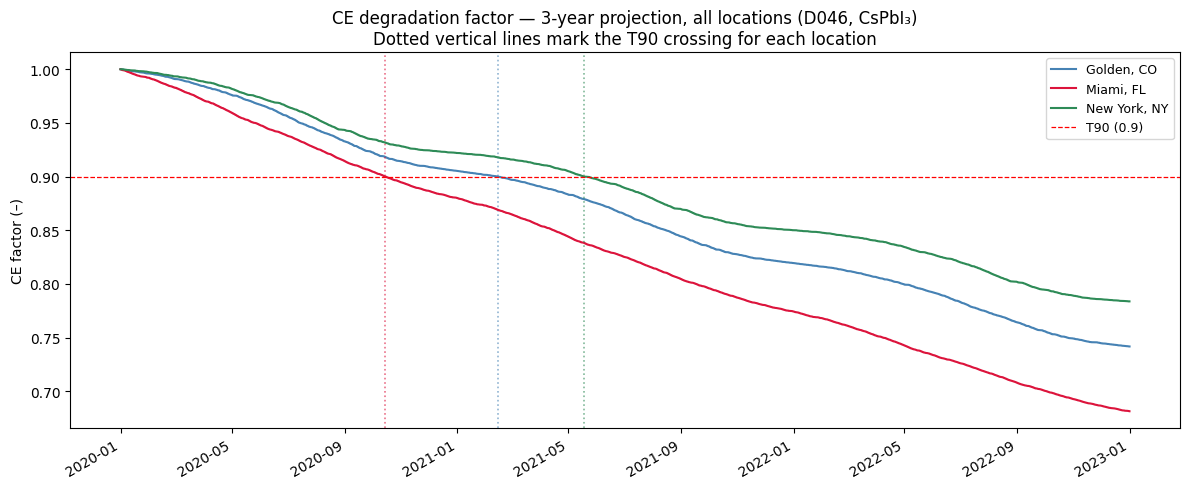

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

for loc, ce in ce_multiyear.items():
    ce.plot(ax=ax, label=loc, color=_colors[loc])
    # Mark the first threshold crossing with a dotted vertical line
    t_idx = ce[ce <= T_THRESHOLD].index
    if len(t_idx):
        ax.axvline(
            t_idx[0], color=_colors[loc], linestyle=":", alpha=0.6, linewidth=1.2
        )

ax.axhline(
    T_THRESHOLD,
    color="red",
    linestyle="--",
    linewidth=0.9,
    label=f"{T_LABEL} ({T_THRESHOLD})",
)
ax.set_ylabel("CE factor (–)")
ax.set_title(
    f"CE degradation factor — {N_YEARS}-year projection, all locations (D046, CsPbI₃)\n"
    f"Dotted vertical lines mark the {T_LABEL} crossing for each location"
)
ax.legend(fontsize=9)
fig.tight_layout()

---
## 6. Lifetime map — US state choropleth via NSRDB PSM4

Each state is coloured by how many months it takes until the **cumulative energy yield**
(`PR_Agg`) falls below `T_THRESHOLD`using a 3-year tiled PSM4 TMY. Colour scale: green = long lifetime (good), red = short lifetime (bad).

This is the energy-yield answer to "when have I lost `(1 − T_THRESHOLD) × 100 %` of my
investment?".


**Note on DF_total**
$DF_{total}$ is the *instantaneous* CE at a given hour, $PR_{Agg}$ is the averaged energy
yield over the whole operating period.

In [9]:
# Fetch lifetime data for all 50 US states via NSRDB PSM4 API
# Get a free key at https://developer.nrel.gov/signup/

API_KEY = "7SNYG6jZv3arhg1hKj1zWI0Y9gO1mXUBvhsK2b1J"
EMAIL = "rajiv.daxini@nlr.gov"

# abbr: (api_lat, api_lon, label, centre_lat, centre_lon)
# (UN)COMMENT whichever states you want
STATES = {
    # "AL": (32.36, -86.30, "Montgomery, AL", 32.8, -86.8),
    # "AK": (61.22, -149.90, "Anchorage, AK", 64.2, -153.0),
    "AZ": (33.45, -112.07, "Phoenix, AZ", 34.3, -111.1),
    # "AR": (34.74, -92.33, "Little Rock, AR", 34.8, -92.2),
    # "CA": (34.05, -118.24, "Los Angeles, CA", 37.2, -119.5),
    # "CO": (39.73, -104.98, "Denver, CO", 39.0, -105.5),
    # "CT": (41.76, -72.68, "Hartford, CT", 41.6, -72.7),
    # "DE": (39.16, -75.52, "Dover, DE", 39.0, -75.5),
    "FL": (25.77, -80.19, "Miami, FL", 27.8, -81.6),
    # "GA": (33.75, -84.39, "Atlanta, GA", 32.7, -83.4),
    "HI": (21.31, -157.86, "Honolulu, HI", 20.5, -157.3),
    # "ID": (43.61, -116.20, "Boise, ID", 44.4, -114.6),
    # "IL": (41.88, -87.63, "Chicago, IL", 40.0, -89.2),
    # "IN": (39.77, -86.16, "Indianapolis, IN", 40.3, -86.1),
    # "IA": (41.59, -93.62, "Des Moines, IA", 42.0, -93.5),
    # "KS": (39.05, -95.69, "Topeka, KS", 38.5, -98.4),
    # "KY": (38.25, -85.76, "Louisville, KY", 37.5, -85.3),
    # "LA": (29.95, -90.07, "New Orleans, LA", 31.1, -91.8),
    "ME": (43.66, -70.26, "Portland, ME", 45.4, -69.2),
    # "MD": (38.97, -76.49, "Annapolis, MD", 39.0, -76.7),
    # "MA": (42.36, -71.06, "Boston, MA", 42.3, -71.8),
    # "MI": (42.73, -84.56, "Lansing, MI", 44.3, -85.4),
    # "MN": (44.94, -93.09, "Minneapolis, MN", 46.4, -93.1),
    # "MS": (32.30, -90.18, "Jackson, MS", 32.7, -89.7),
    # "MO": (38.57, -92.17, "Jefferson City, MO", 38.4, -92.5),
    # "MT": (46.60, -112.02, "Helena, MT", 47.0, -110.4),
    # "NE": (40.81, -96.68, "Lincoln, NE", 41.5, -99.9),
    # "NV": (36.17, -115.14, "Las Vegas, NV", 39.3, -116.6),
    # "NH": (43.21, -71.54, "Concord, NH", 43.7, -71.6),
    # "NJ": (40.22, -74.76, "Trenton, NJ", 40.1, -74.5),
    # "NM": (35.67, -105.96, "Santa Fe, NM", 34.4, -106.1),
    # "NY": (40.71, -74.01, "New York, NY", 42.9, -75.6),
    # "NC": (35.78, -78.64, "Raleigh, NC", 35.5, -79.4),
    # "ND": (46.81, -100.78, "Bismarck, ND", 47.5, -100.5),
    # "OH": (39.96, -82.99, "Columbus, OH", 40.4, -82.8),
    # "OK": (35.47, -97.52, "Oklahoma City, OK", 35.6, -97.5),
    # "OR": (44.94, -123.03, "Salem, OR", 44.1, -120.5),
    # "PA": (40.27, -76.88, "Harrisburg, PA", 40.9, -77.8),
    # "RI": (41.82, -71.42, "Providence, RI", 41.7, -71.5),
    # "SC": (34.00, -81.03, "Columbia, SC", 33.9, -80.9),
    # "SD": (44.37, -100.35, "Pierre, SD", 44.4, -100.2),
    # "TN": (36.16, -86.78, "Nashville, TN", 35.9, -86.4),
    "TX": (31.76, -106.49, "El Paso, TX", 31.5, -99.3),
    # "UT": (40.76, -111.89, "Salt Lake City, UT", 39.4, -111.1),
    # "VT": (44.26, -72.58, "Montpelier, VT", 44.0, -72.7),
    # "VA": (37.54, -77.43, "Richmond, VA", 37.5, -78.9),
    "WA": (47.61, -122.33, "Seattle, WA", 47.4, -120.6),
    # "WV": (38.35, -81.63, "Charleston, WV", 38.6, -80.6),
    # "WI": (43.07, -89.40, "Madison, WI", 44.3, -89.8),
    # "WY": (41.14, -104.82, "Cheyenne, WY", 43.0, -107.6),
}

map_data = []
pr_series = {}  # PR_Agg(t) trajectory per location (for the over-time plot)
ce_series = {}  # CE(t) = DF_total trajectory per location (for the Fig 4 CE check)
for abbr, (lat, lon, label, clat, clon) in STATES.items():
    try:
        wdf, mt = pvdeg.weather.get(
            database="PSM4",
            id=(lat, lon),
            api_key=API_KEY,
            email=EMAIL,
            year="tmy",
            map_variables=True,
        )
        wdf.index = wdf.index.map(lambda ts: ts.replace(year=2020))
        wdf = wdf.sort_index()
        tilt = abs(mt["latitude"])  # latitude-tilt, south-facing — passed explicitly

        # CE factor (DF_total) threshold crossing — device-level
        ce = run_ce_multiyear(wdf, mt)
        ce_series[abbr] = ce
        t_df_idx = ce[ce <= T_THRESHOLD].index
        t_df_m = (t_df_idx[0] - ce.index[0]).days / 30.44 if len(t_df_idx) else None

        # PR_Agg threshold crossing — cumulative energy-yield metric
        wdf_ny = make_multiyear(wdf, N_YEARS)
        sc_s = pvdeg.Scenario(name=f"ey-{abbr}", weather_data=wdf_ny, meta_data=mt)
        sc_s.addJob(
            func=(
                pvdeg.spectral.poa_irradiance,
                {
                    "surface_tilt": tilt,
                    "surface_azimuth": 180.0,
                },
            ),
            name="poa",
        )
        sc_s.addJob(
            func=pvdeg.temperature.module, name="temp_mod", depends_on={"poa": "poa"}
        )
        sc_s.addJob(
            func=(
                pvdeg.degradation.perovskite_degradation_factor,
                {"parameters": d046},
            ),
            name="ce_factor",
            depends_on={"poa": "poa"},
        )
        sc_s.run()
        ey_s = pvdeg.degradation.degraded_power_ratio(
            weather_df=wdf_ny,
            meta=mt,
            ce_factor=sc_s.results["ce_factor"],
            poa=sc_s.results["poa"],
            temp_cell=sc_s.results["temp_mod"],
            **TOP_CELL_PARAM,
        )
        pr_s = ey_s[
            "PR_Agg"
        ]  # degraded_power_ratio returns a dict; take the PR_Agg series
        pr_series[abbr] = pr_s
        cum_poa = float(sc_s.results["poa"]["poa_global"].sum()) / 1000.0 / N_YEARS
        t_pr_idx = pr_s[pr_s <= T_THRESHOLD].index
        t_pr_m = (t_pr_idx[0] - pr_s.index[0]).days / 30.44 if len(t_pr_idx) else None

        map_data.append(
            {
                "state": abbr,
                "location": label,
                "centre_lat": clat,
                "centre_lon": clon,
                "T_months": t_pr_m,
                "T_DF_months": t_df_m,
                "cum_poa_kwh": round(cum_poa, 0),
            }
        )
        t_str = (
            f"{t_pr_m:.1f} mo (PR_Agg)  /  {t_df_m:.1f} mo (DF)"
            if t_pr_m
            else f">{N_YEARS}y"
        )
        print(f"  {abbr}: {T_LABEL} = {t_str}")
    except Exception as exc:
        print(f"  {abbr}: FAILED — {exc}")

df_map = pd.DataFrame(map_data)
print(f"\nFetched {len(df_map)} / {len(STATES)} states successfully.")
print(
    f"Map colour = PR_Agg {T_LABEL}  (energy-yield metric, consistent with Orooji et al.)"
)

The array surface_tilt angle was not provided, therefore the latitude of  33.5 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
The array surface_tilt angle was not provided, therefore the latitude of  33.5 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
  AZ: T90 = 13.9 mo (PR_Agg)  /  6.8 mo (DF)
The array surface_tilt angle was not provided, therefore the latitude of  25.8 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
The array surface_tilt angle was not provided, therefore the latitude of  25.8 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
  FL: T90 = 18.2 mo (PR_Agg)  /  9.4 mo (DF)
The array surface_tilt angle was not provided, therefore the latitude of  21.3 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
The array surface_tilt angle was not provided, therefore the latitude of  21.3 w

In [10]:
# Plot: PR_Agg lifetime choropleth with state abbreviation labels
# This cell can be re-run with adjusted formatting without re-fetching API data.

if df_map.empty:
    print("No data in df_map — run the cell above first with valid API credentials.")
else:
    fig_map = px.choropleth(
        df_map,
        locations="state",
        locationmode="USA-states",
        color="T_months",
        scope="usa",
        hover_name="location",
        hover_data={
            "state": False,
            "T_months": True,
            "T_DF_months": True,
        },
        color_continuous_scale="RdYlGn",
        labels={
            "T_months": f"PR_Agg {T_LABEL} (months)",
            "T_DF_months": f"DF_total {T_LABEL} (months)",
        },
        title=(
            f"Energy-yield {T_LABEL} by US state  (PR_Agg < {T_THRESHOLD})<br>"
            f"<sup>D046 (CsPbI₃), {N_YEARS}-year tiled PSM4 TMY — "
            f"hover for DF_total {T_LABEL}</sup>"
        ),
    )

    labelled = df_map[df_map["T_months"].notna()]
    fig_map.add_trace(
        go.Scattergeo(
            lat=labelled["centre_lat"].tolist(),
            lon=labelled["centre_lon"].tolist(),
            text=labelled["state"].tolist(),
            mode="text",
            textfont=dict(size=8, color="black", family="Arial"),
            hoverinfo="skip",
            showlegend=False,
        )
    )

    fig_map.update_layout(
        coloraxis_colorbar=dict(title=f"PR_Agg {T_LABEL}<br>(months)")
    )
    fig_map.show()

## 7. Comparison with the original publication

Comparison between reference publication and this worklfow.

Note on differences:
- **Weather:** pvdeg uses NSRDB PSM4 `"tmy"` and PVGIS TMY; Orooji used NREL/NLR TMY3.
- **Device:** single-junction perovskite cell here vs Orooji's two-diode Si/Perovskite tandem.

If at least the CE can be reproduced for this top cell, independent of total degradation,
this suggests that the workflow is succesfully validating the published results. Further
differences in the T90_Agg may be attributed to the different device architectures. While
this example considers single-junction performance from a single perovskite cell, which
exhibits degradation, the reference publication uses a tandem Si/Pk configuration. In
the tandem architecture, the Si cell exhibits less degradation, which will mask performance
loss due to top cell (perovskite) degradation when the Si cell is limiting in the field.
Therefore, the tandem is likely to exhibit a longer T90_Agg, but overall the location
ranking should be the same.

In [11]:
# Publication comparison: data prep
# PSM4 for all six states is already computed in the US-map fetch cell, this is used for
# T_90_Agg, CE, and PR_Agg comparison. PVGIS TMY is added for the two locations plotted
# in the reference publication (Phoenix and Seattle) to compare CE and PR_Agg.

# Orooji published reference values
OROOJI_T90 = {
    "AZ": 26,
    "TX": 29,
    "HI": 32,
    "FL": 35,
    "ME": 40,
    "WA": 42,
}  # Fig 5 / abstract
OROOJI_FIG4 = {
    "AZ": (0.83, 0.95),
    "WA": (0.90, 0.97),
}  # (CE, PR_Agg) at 12 months, Fig 4
CLIMATE = {
    "AZ": "arid",
    "TX": "arid",
    "FL": "tropical",
    "HI": "tropical",
    "WA": "temperate",
    "ME": "temperate",
}
_ccolor = {"arid": "#d95f02", "temperate": "#1b9e77", "tropical": "#7570b3"}


def _at_one_year(series):
    """Value of a tiled multi-year series at the 12-month mark."""
    return float(series.asof(series.index[0] + pd.DateOffset(years=1)))


def ey_pipeline(wdf, mt):
    """POA -> module temp -> CE (DF_total) -> PR_Agg on an N_YEARS tiling.

    CE is computed once in the Scenario and reused for the power step.
    Returns (CE_series, PR_Agg_series).
    """
    wdf_ny = make_multiyear(wdf, N_YEARS)
    sc = pvdeg.Scenario(name="ey-cmp", weather_data=wdf_ny, meta_data=mt)
    sc.addJob(
        func=(
            pvdeg.spectral.poa_irradiance,
            {"surface_tilt": abs(mt["latitude"]), "surface_azimuth": 180.0},
        ),
        name="poa",
    )
    sc.addJob(func=pvdeg.temperature.module, name="temp_mod", depends_on={"poa": "poa"})
    sc.addJob(
        func=(pvdeg.degradation.perovskite_degradation_factor, {"parameters": d046}),
        name="ce_factor",
        depends_on={"poa": "poa"},
    )
    sc.run()
    ce = sc.results["ce_factor"]
    pr = pvdeg.degradation.degraded_power_ratio(
        weather_df=wdf_ny,
        meta=mt,
        ce_factor=ce,
        poa=sc.results["poa"],
        temp_cell=sc.results["temp_mod"],
        **TOP_CELL_PARAM,
    )["PR_Agg"]
    return ce, pr


# PVGIS TMY for the two Fig-4 sites (PSM4 for these is already in ce_series / pr_series)
pvgis_ce, pvgis_pr = {}, {}
for st, (lat, lon) in {"AZ": (33.45, -112.07), "WA": (47.61, -122.33)}.items():
    data, _ = pvlib.iotools.get_pvgis_tmy(
        latitude=lat, longitude=lon, map_variables=True
    )
    wdf = data.copy()
    wdf.index = wdf.index.map(lambda ts: ts.replace(year=2020))
    wdf = wdf.sort_index()
    mt = {"latitude": lat, "longitude": lon, "altitude": 0, "wind_height": 10}
    pvgis_ce[st], pvgis_pr[st] = ey_pipeline(wdf, mt)
    print(f"  {st}: PVGIS TMY fetched ({len(wdf)} rows)")

The array surface_tilt angle was not provided, therefore the latitude of  33.5 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
  AZ: PVGIS TMY fetched (8760 rows)
The array surface_tilt angle was not provided, therefore the latitude of  47.6 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
  WA: PVGIS TMY fetched (8760 rows)


CE & PR_Agg at 12 months  (PSM4 / PVGIS / Orooji Fig 4):
loc  CE_PSM4  CE_PVGIS  CE_Orooji  PRagg_PSM4  PRagg_PVGIS  PRagg_Orooji
 AZ    0.837     0.845       0.83       0.911        0.915          0.95
 WA    0.937     0.942       0.90       0.966        0.969          0.97


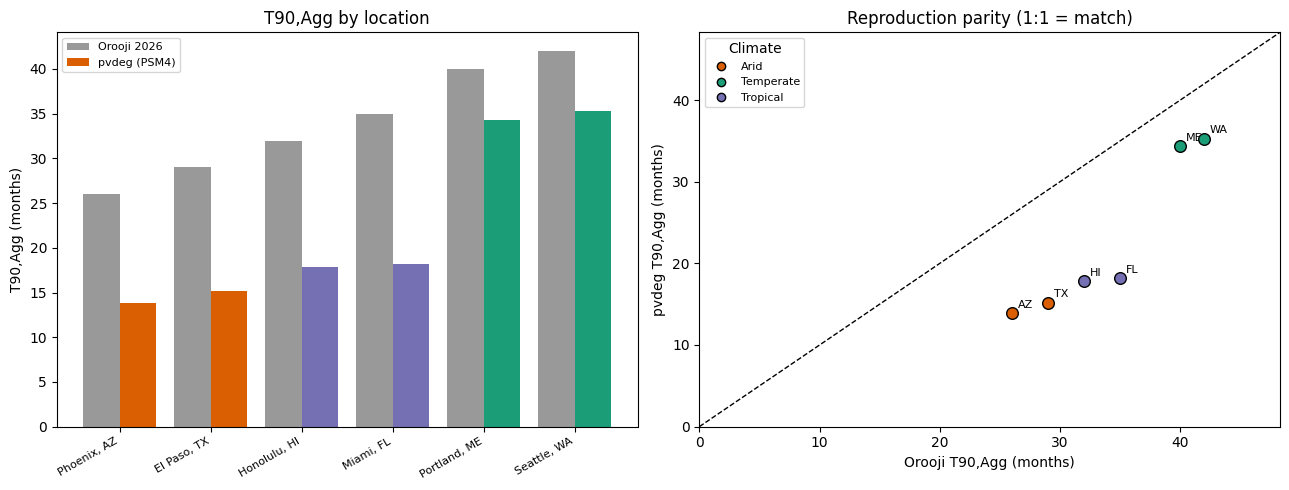

In [12]:
# Publication comparison: plots + 12-month table
if df_map.empty:
    print("df_map is empty - run the US-map fetch cell first.")
else:
    # T90,Agg by location
    # PSM4 is used for the 6-location view (more leniant rate limits)
    cmp = df_map.copy()
    cmp["orooji_T90"] = cmp["state"].map(OROOJI_T90)
    cmp["climate"] = cmp["state"].map(CLIMATE)
    cmp = cmp.dropna(subset=["T_months", "orooji_T90"]).sort_values("orooji_T90")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    xpos, w = np.arange(len(cmp)), 0.4
    ax1.bar(xpos - w / 2, cmp["orooji_T90"], w, label="Orooji 2026", color="0.6")
    ax1.bar(
        xpos + w / 2,
        cmp["T_months"],
        w,
        label="pvdeg (PSM4)",
        color=[_ccolor[c] for c in cmp["climate"]],
    )
    ax1.set_xticks(xpos)
    ax1.set_xticklabels(cmp["location"], rotation=30, ha="right", fontsize=8)
    ax1.set_ylabel(f"{T_LABEL},Agg (months)")
    ax1.set_title(f"{T_LABEL},Agg by location")
    ax1.legend(fontsize=8)

    lim = max(cmp["orooji_T90"].max(), cmp["T_months"].max()) * 1.15
    ax2.plot([0, lim], [0, lim], "k--", lw=1, label="1:1")
    for _, r in cmp.iterrows():
        ax2.scatter(
            r["orooji_T90"],
            r["T_months"],
            s=70,
            color=_ccolor[r["climate"]],
            edgecolor="k",
            zorder=3,
        )
        ax2.annotate(
            r["state"],
            (r["orooji_T90"], r["T_months"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
        )
    ax2.set_xlim(0, lim)
    ax2.set_ylim(0, lim)
    ax2.set_xlabel(f"Orooji {T_LABEL},Agg (months)")
    ax2.set_ylabel(f"pvdeg {T_LABEL},Agg (months)")
    ax2.set_title("Reproduction parity (1:1 = match)")
    ax2.legend(
        handles=[
            Line2D(
                [0],
                [0],
                marker="o",
                ls="",
                color=c,
                label=k.title(),
                markeredgecolor="k",
            )
            for k, c in _ccolor.items()
        ],
        fontsize=8,
        title="Climate",
    )
    fig.tight_layout()

    # CE & PR_Agg at 12 months - only the two sites Orooji plots in Fig 4 (AZ, WA).
    rows = []
    for st in OROOJI_FIG4:
        rows.append(
            {
                "loc": st,
                "CE_PSM4": round(_at_one_year(ce_series[st]), 3),
                "CE_PVGIS": round(_at_one_year(pvgis_ce[st]), 3),
                "CE_Orooji": OROOJI_FIG4[st][0],
                "PRagg_PSM4": round(_at_one_year(pr_series[st]), 3),
                "PRagg_PVGIS": round(_at_one_year(pvgis_pr[st]), 3),
                "PRagg_Orooji": OROOJI_FIG4[st][1],
            }
        )
    print("CE & PR_Agg at 12 months  (PSM4 / PVGIS / Orooji Fig 4):")
    print(pd.DataFrame(rows).to_string(index=False))